# Soild SVR in depth analysis
2025-11-05, Alexander Minidis

2025-11-06 added Support vector with optimization,

07: outlier removed

16: with/without oulier and functions moved to ML_tools
uses statsmodel, doesn't work with Py3.13 and UV...

In [1]:
from typing import Any
from pathlib import Path
import pandas as pd
import numpy as np

import sqlalchemy as sa
from sqlalchemy.orm import sessionmaker
from src.db_schema import *
from src.db_utils import get_selected_data
from src.rdkit_tools import MACCS_NAMES
from src.legacy.ml_tools import drop_irrelevant_columns, scale_features, remove_variance_and_correlation, output_metrics
from src.legacy.ml_tools import detect_and_remove_outliers
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import BayesianRidge
from sklearn.svm import SVR
import xgboost as xgb
import seaborn as sns
from scipy import stats
# from sklearn.metrics import mean_squared_error, r2_score, explained_variance_score, mean_absolute_error, root_mean_squared_error

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 250)

In [2]:
# set directories and filenames, load database
working_dir = Path.cwd()
data_dir = working_dir / "processed_data"
database_file = data_dir / "t_half_all.db"
engine = sa.create_engine(f"sqlite:///{database_file}")
Session = sessionmaker(bind=engine)
# get all data
air_data = get_selected_data("air", Session)
soil_data = get_selected_data("soil", Session)
water_data = get_selected_data("water", Session)
sediment_data = get_selected_data("sediment", Session)

In [3]:
# model settings
# air_data = drop_irrelevant_columns(air_data, to_drop=["None"])
# water_data = drop_irrelevant_columns(water_data, to_drop=["None"])
soil_data = drop_irrelevant_columns(soil_data, to_drop=["None"])
# sediment_data = drop_irrelevant_columns(sediment_data)

target_column = "T_half_days"
data_to_use = soil_data.copy()
use_outlier_removal = False

## Preprocessing

In [4]:
# we will only use water data for now
X, y = data_to_use.drop(columns=[target_column]), data_to_use[target_column]
print(f"Number of features: {X.shape[1]}, number of samples: {X.shape[0]}")

Number of features: 375, number of samples: 669


In [5]:
print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Any NaNs in X? {X.isna().any().any()}")
print(f"Any NaNs in y? {y.isna().any()}")
nan_mask = ~(X.isna().any(axis=1) | y.isna())
X = X[nan_mask]
y = y[nan_mask]
print(f"After dropping NaNs: {X.shape[0]} samples remain.")

X shape: (669, 375), y shape: (669,)
Any NaNs in X? True
Any NaNs in y? False
After dropping NaNs: 659 samples remain.


### 1. Outlier detection

In [6]:
if use_outlier_removal:
    X_clean, y_clean = detect_and_remove_outliers(X, y)
    print(f"Cleaned dataset: {X_clean.shape[0]} samples, {X_clean.shape[1]} features.")
    del X, y
    X = X_clean.copy()
    y = y_clean.copy()
else:
    print("Outlier removal not applied.")

Outlier removal not applied.


### 2. Scaling/normalization

In [7]:
X_scaled = scale_features(X)
X_decorrelated = remove_variance_and_correlation(X_scaled, target_column)

Number of features: 342, number of samples: 659
Number of features: 302, number of samples: 659
Number of features: 302, number of samples: 659


## Model

In [8]:
X = X_decorrelated.copy()
y = np.log10(y)

In [9]:
# Drop rows with NaN in X or y before train/test split
nan_mask = ~(X.isna().any(axis=1) | y.isna())
X = X[nan_mask]
y = y[nan_mask]
print(f"After dropping NaNs: {X.shape[0]} samples remain.")

After dropping NaNs: 659 samples remain.


C:\Users\u93099\AppData\Local\Temp\2\ipykernel_3556\1936453274.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X = X[nan_mask]


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## SVR

In [11]:
# # Support Vector Regression (SVR) model
# param_grid = {
#     'C': [0.1, 1, 10, 100],
#     'epsilon': [0.01, 0.1, 0.2, 0.5],
#     'kernel': ['rbf', 'linear'],
#     'gamma': ['scale', 'auto']
# }

# svr = SVR()
# grid_search = GridSearchCV(svr, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
# grid_search.fit(X_train, y_train)

# print("Best parameters:", grid_search.best_params_)
# best_svr = grid_search.best_estimator_

In [12]:
# svr = best_svr
svr = SVR(C=1, epsilon=0.01, gamma="auto", kernel="rbf")
svr.fit(X_train, y_train)
y_pred_svr = svr.predict(X_test)

# Inverse transform predictions and targets
y_test_exp_svr = np.power(10, y_test)
y_pred_exp_svr = np.power(10, y_pred_svr)
print("SVR metrics:")
output_metrics(y_test_exp_svr, y_pred_exp_svr)

SVR metrics:
R2: 0.071
MAE: 434.047
MSE: 12245498.312
RMSE: 3499.357
Explained Variance: 0.082
RMSE: 3499.357
Explained Variance: 0.082
RMSE: 3499.357
Explained Variance: 0.082
RMSE: 3499.357
Explained Variance: 0.082


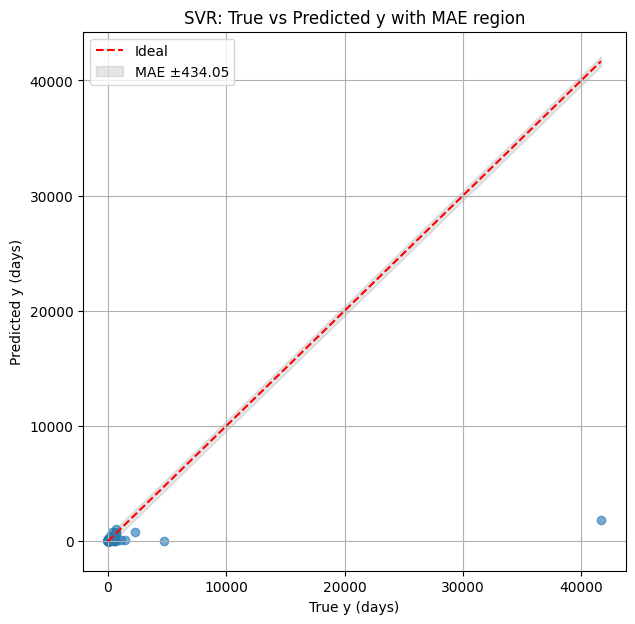

In [13]:
# SVR true vs predicted plot
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test_exp_svr, y_pred_exp_svr)
plt.figure(figsize=(7, 7))
plt.scatter(y_test_exp_svr, y_pred_exp_svr, alpha=0.6)
plt.plot([min(y_test_exp_svr), max(y_test_exp_svr)], [min(y_test_exp_svr), max(y_test_exp_svr)], "r--", label="Ideal")
plt.fill_between(
    [min(y_test_exp_svr), max(y_test_exp_svr)],
    [min(y_test_exp_svr) + mae, max(y_test_exp_svr) + mae],
    [min(y_test_exp_svr) - mae, max(y_test_exp_svr) - mae],
    color="gray",
    alpha=0.2,
    label=f"MAE ±{mae:.2f}",
)
plt.xlabel("True y (days)")
plt.ylabel("Predicted y (days)")
plt.title("SVR: True vs Predicted y with MAE region")
plt.legend()
plt.grid(True)
plt.show()

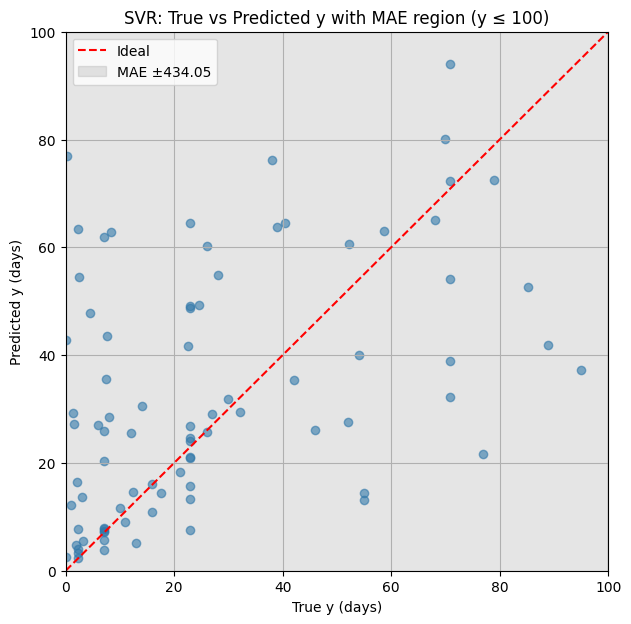

In [14]:
# Add shaded region for MAE to SVR true vs predicted plot, limited to x/y <= 100
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test_exp_svr, y_pred_exp_svr)
plt.figure(figsize=(7, 7))
# Only plot points where both true and predicted are <= 100
mask = (y_test_exp_svr <= 100) & (y_pred_exp_svr <= 100)
plt.scatter(y_test_exp_svr[mask], y_pred_exp_svr[mask], alpha=0.6)
plt.plot([0, 100], [0, 100], "r--", label="Ideal")
plt.fill_between([0, 100], [mae, 100 + mae], [-mae, 100 - mae], color="gray", alpha=0.2, label=f"MAE ±{mae:.2f}")
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.xlabel("True y (days)")
plt.ylabel("Predicted y (days)")
plt.title("SVR: True vs Predicted y with MAE region (y ≤ 100)")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
# Plot top ten features by permutation importance for SVR
from sklearn.inspection import permutation_importance

result = permutation_importance(svr, X_test, y_test, n_repeats=10, random_state=42, scoring="neg_mean_squared_error")

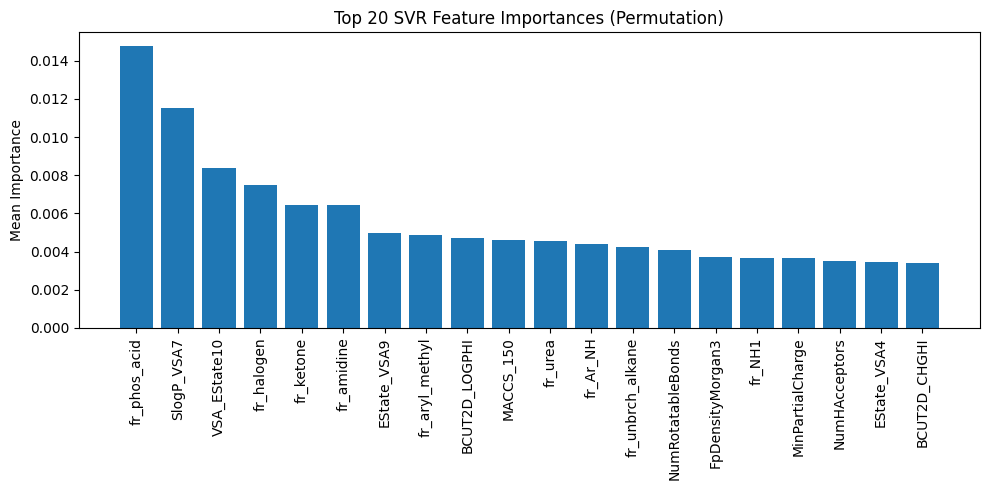

In [16]:
importances = result.importances_mean
num_of_feats = 20
indices = np.argsort(importances)[::-1][:num_of_feats]
plt.figure(figsize=(10, 5))
plt.bar(range(num_of_feats), importances[indices])
plt.xticks(range(num_of_feats), X_test.columns[indices], rotation=90)
plt.title(f"Top {num_of_feats} SVR Feature Importances (Permutation)")
plt.ylabel("Mean Importance")
plt.tight_layout()
plt.show()

Analysis of SVR

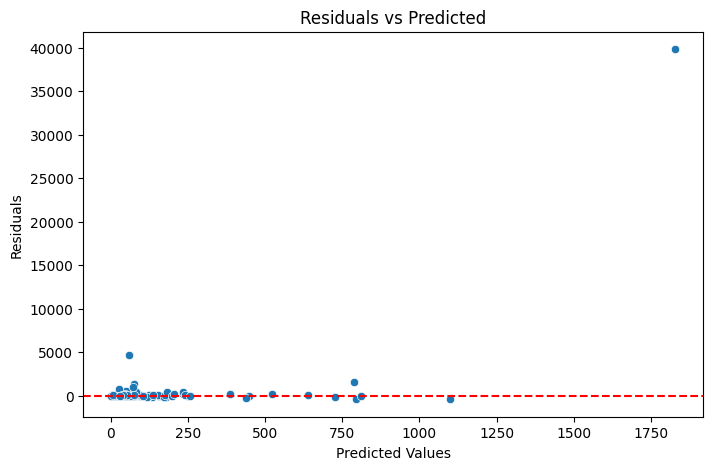

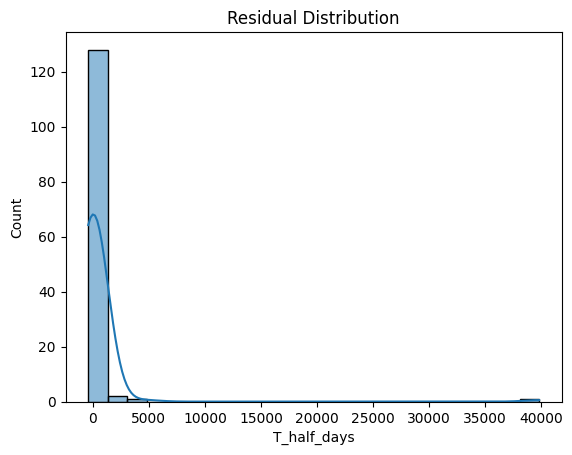

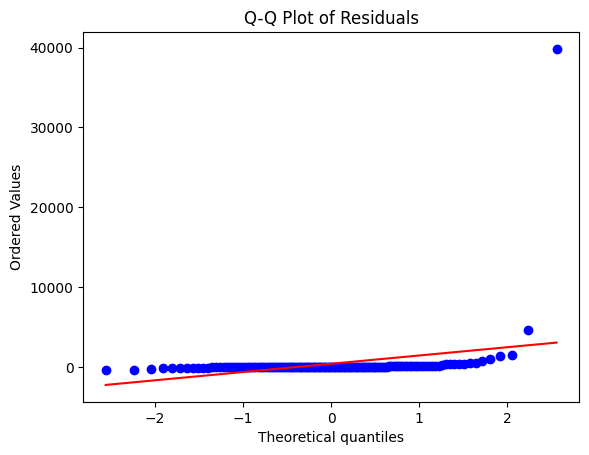

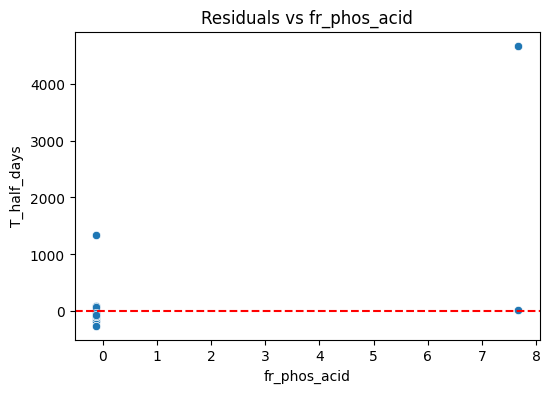

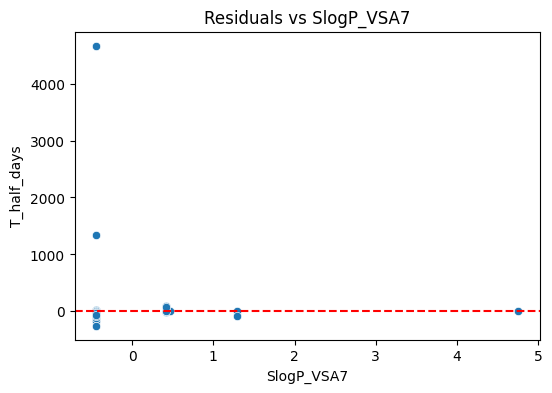

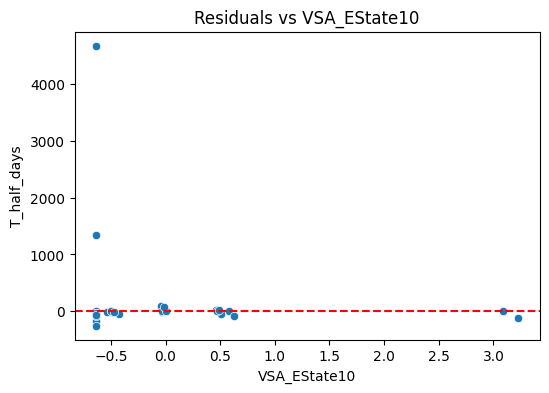

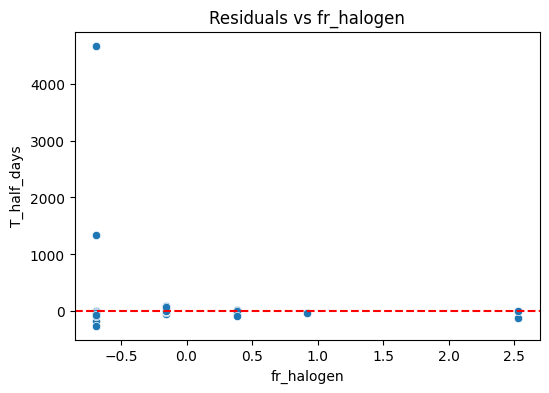

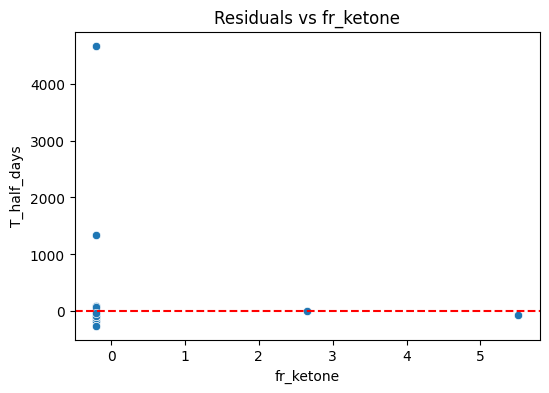

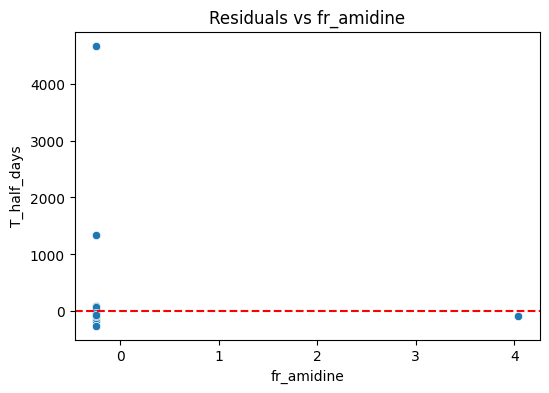

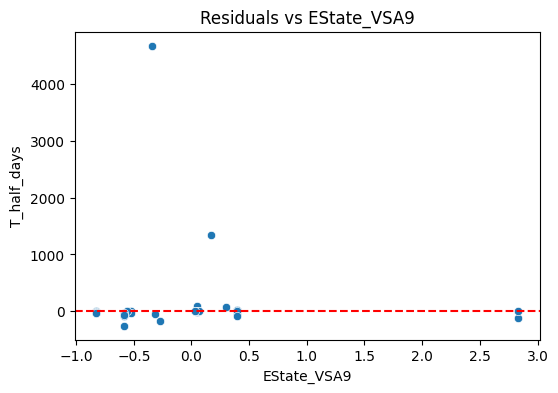

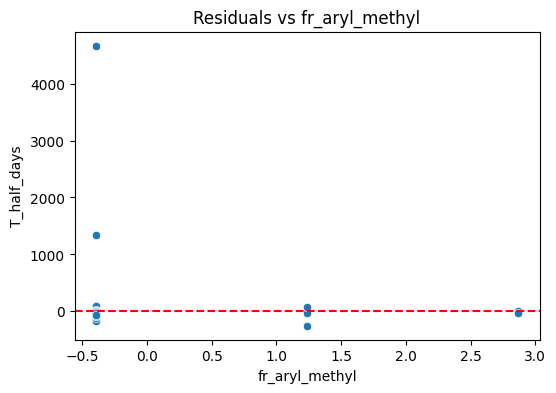

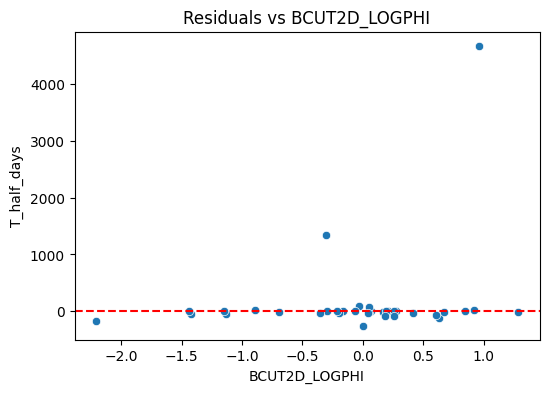

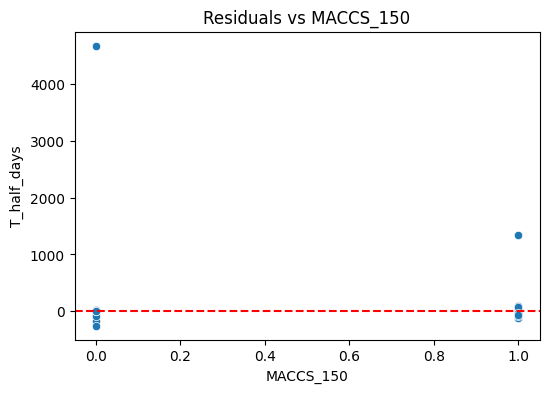

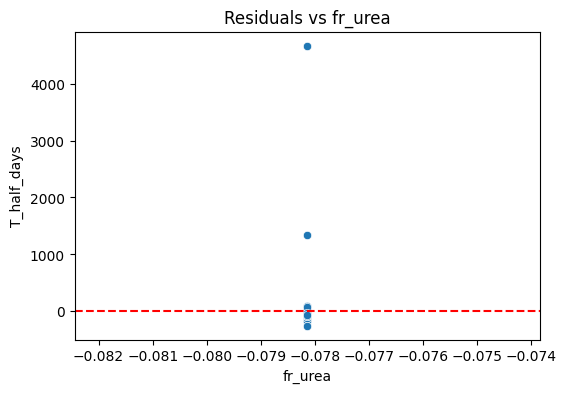

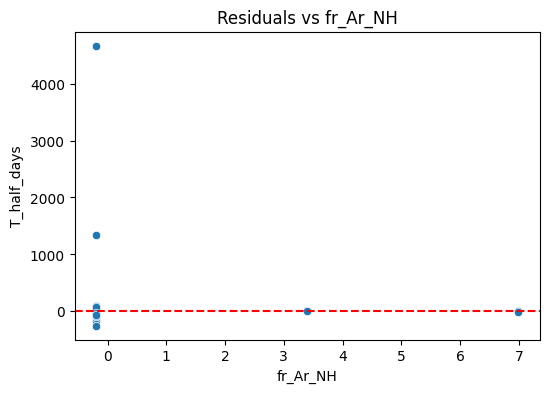

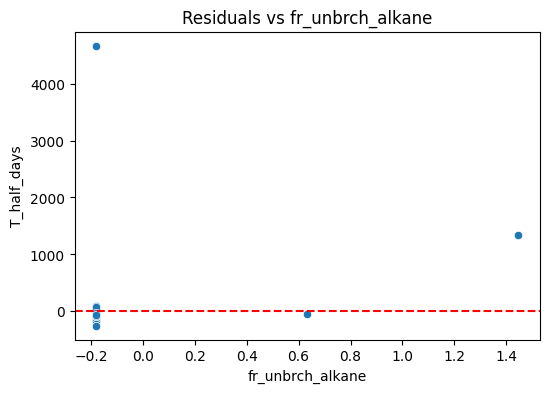

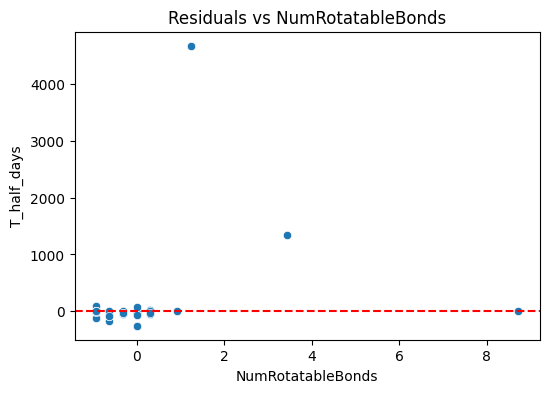

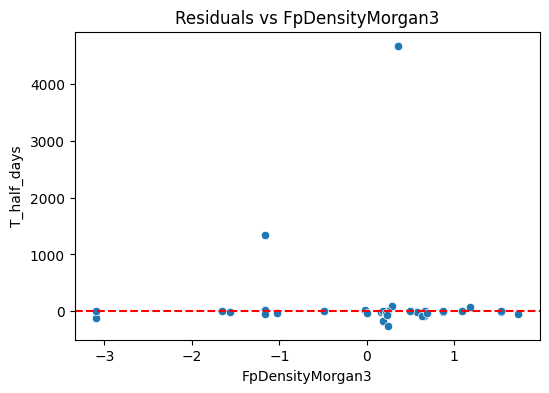

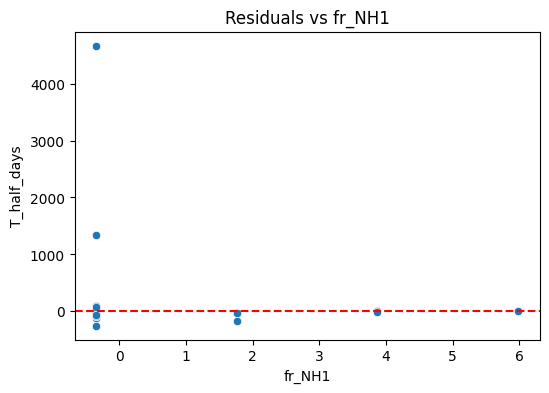

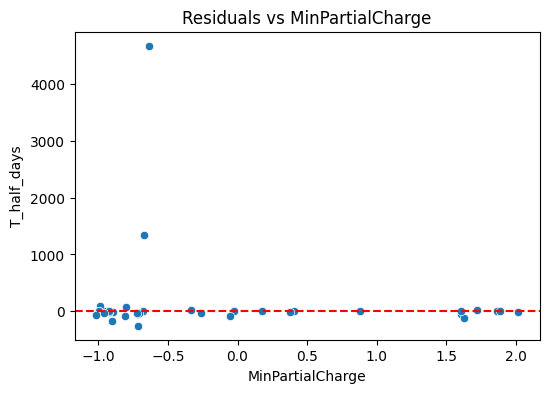

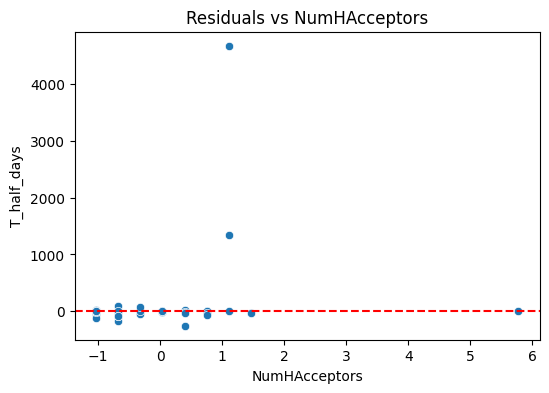

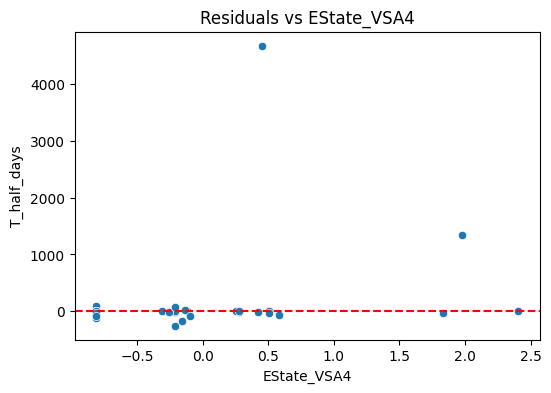

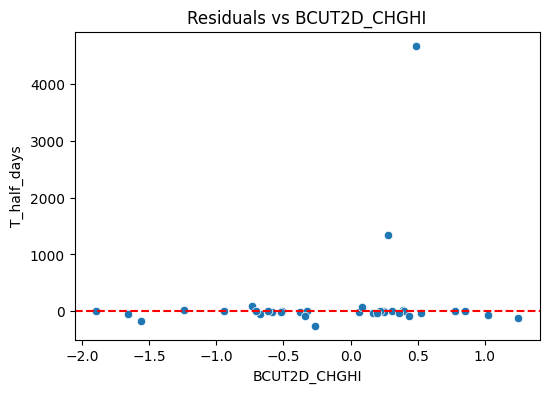

In [17]:
residuals = y_test_exp_svr - y_pred_exp_svr

# Scatter plot: Residuals vs Predicted
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred_exp_svr, y=residuals)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

# Histogram of residuals
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()


# Q-Q Plot using SciPy
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

# Residuals vs Top Features by Permutation Importance
for col in X_test.columns[indices]:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=X_test[col], y=residuals)
    plt.axhline(0, color="red", linestyle="--")
    plt.title(f"Residuals vs {col}")
    plt.show()